In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap

import matplotlib.pyplot as plt
from qutip import Bloch
import qutip

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

from tqdm import tqdm
from sklearn.metrics import classification_report

import json
import pandas as pd

from collections import defaultdict
import matplotlib as mpl
from matplotlib import cm

from qutip import basis, sigmax, sigmay, sigmaz, tensor, mesolve, Qobj, qeye, destroy
from qutip import fidelity as fidelity_qutip

In [2]:
import os

In [3]:
def representatives(classes, qubits_lab):
  """
  This function creates the label states for the classification task
  INPUT:
      -classes: number of classes of our problem
      -qubits_lab: how many qubits will store the labels
  OUTPUT:
      -reprs: the label states
  """
  reprs = np.zeros((classes, 2**qubits_lab), dtype = 'complex', requires_grad=False)
  if qubits_lab == 1:
      if classes == 0:
          raise ValueError('Nonsense classifier')
      if classes == 1:
          raise ValueError('Nonsense classifier')
      if classes == 2:
          reprs[0] = np.array([1, 0])
          reprs[1] = np.array([0, 1])
      if classes == 3:
          reprs[0] = np.array([1, 0])
          reprs[1] = np.array([1 / 2, np.sqrt(3) / 2])
          reprs[2] = np.array([1 / 2, -np.sqrt(3) / 2])
      if classes == 4:
          reprs[0] = np.array([1, 0])
          reprs[1] = np.array([1 / np.sqrt(3), np.sqrt(2 / 3)])
          reprs[2] = np.array([1 / np.sqrt(3), np.exp(1j * 2 * np.pi / 3) * np.sqrt(2 / 3)])
          reprs[3] = np.array([1 / np.sqrt(3), np.exp(-1j * 2 * np.pi / 3) * np.sqrt(2 / 3)])
      if classes == 6:
          reprs[0] = np.array([1, 0])
          reprs[1] = np.array([0, 1])
          reprs[2] = 1 / np.sqrt(2) * np.array([1, 1])
          reprs[3] = 1 / np.sqrt(2) * np.array([1, -1])
          reprs[4] = 1 / np.sqrt(2) * np.array([1, 1j])
          reprs[5] = 1 / np.sqrt(2) * np.array([1, -1j])

  if qubits_lab == 2:
      if classes == 0:
          raise ValueError('Nonsense classifier')
      if classes == 1:
          raise ValueError('Nonsense classifier')
      if classes == 2:
          reprs[0] = np.array([1, 0, 0, 0])
          reprs[1] = np.array([0, 0, 0, 1])
      if classes == 3:
          reprs[0] = np.array([1, 0, 0, 0])
          reprs[1] = np.array([0, 1, 0, 0])
          reprs[2] = np.array([0, 0, 1, 0])
      if classes == 4:
          reprs[0] = np.array([1, 0, 0, 0])
          reprs[1] = np.array([0, 1, 0, 0])
          reprs[2] = np.array([0, 0, 1, 0])
          reprs[3] = np.array([0, 0, 0, 1])
  if qubits_lab == 4:
      if classes == 2:
        reprs[0] = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
        reprs[1] = np.array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
      if classes == 3:
        reprs[0] = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
        reprs[1] = np.array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
        reprs[2] = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

  return reprs

def to_spherical(state):
    r0 = np.abs(state[0])
    ϕ0 = np.angle(state[0])
    r1 = np.abs(state[1])
    ϕ1 = np.angle(state[1])
    r = np.sqrt(r0 ** 2 + r1 ** 2)
    θ = 2 * np.arccos(r0 / r)
    ϕ = ϕ1 - ϕ0
    return [r, θ, ϕ]

def to_cartesian(polar):
    r = polar[0]
    θ = polar[1]
    ϕ = polar[2]
    x = r * np.sin(θ) * np.cos(ϕ)
    y = r * np.sin(θ) * np.sin(ϕ)
    z = r * np.cos(θ)
    return [x, y, z]

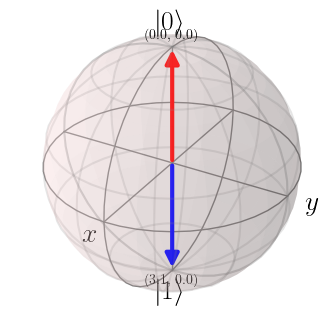

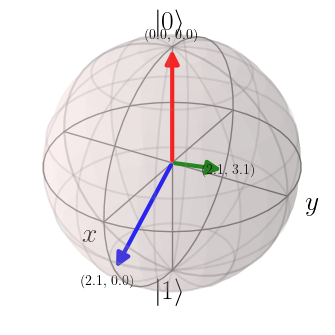

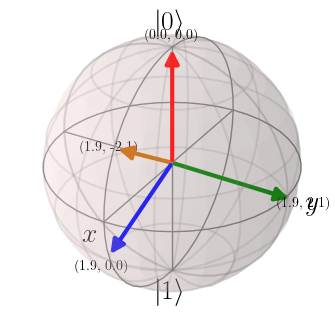

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import qutip
import os

# Configurar las opciones de estilo
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'Times New Roman'

cases = [
    (1, 2, "1q-2c"),
    (1, 3, "1q-3c"),
    (1, 4, "1q-4c")
]

for case_i in cases:
    # Crear una figura y un eje 3D
    fig = plt.figure(constrained_layout=True)
    ax = fig.add_subplot(1, 2, 1, projection='3d')

    b = qutip.Bloch(axes=ax, fig=fig)

    # Obtener los estados y convertir coordenadas
    states = representatives(case_i[1], case_i[0])
    states_sphr = [to_spherical(state_j) for state_j in states]
    states_cart = [to_cartesian(state_j) for state_j in states_sphr]

    # Asignar colores a los vectores
    b.vector_color = ['r', 'b', 'g', '#CC6600']

    for vec_i, sphr_coords in zip(states_cart, states_sphr):
        # Añadir el vector a la esfera de Bloch
        b.add_vectors(vec_i)

        # Extraer theta y phi, convertir a float, y redondear a 1 decimal
        theta = round(float(sphr_coords[1]), 1)
        phi = round(float(sphr_coords[2]), 1)

        # Calcular la posición del texto en la punta del vector
        x_text = vec_i[0] * 1.1  # Ligeramente más lejos para mejor visibilidad
        y_text = vec_i[1] * 1.1
        z_text = vec_i[2] * 1.1

        # Determinar color del texto según el fondo
        text_color = 'black' if abs(vec_i[2]) < 0.7 else 'black'  # Evitar contraste con fondo

        # Agregar el texto usando la función de qutip
        b.add_annotation([x_text, y_text, z_text], f"({theta}, {phi})", color=text_color, fontsize=10)

    b.render()

    # Guardar la imagen en PDF con espacio en blanco ajustado
    path_to_save = os.path.join('results_to_paper', f"labeled_{case_i[2]}.pdf")
    plt.savefig(path_to_save, format='pdf', bbox_inches='tight')

    plt.show()


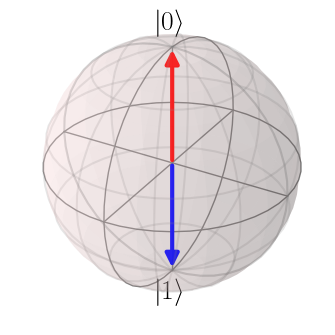

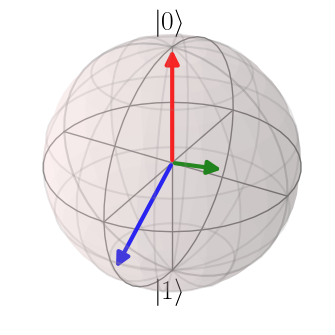

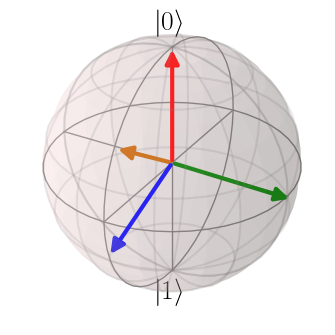

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import qutip
import os

# Configurar las opciones de estilo
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'Times New Roman'

cases = [
    (1, 2, "1q-2c"),
    (1, 3, "1q-3c"),
    (1, 4, "1q-4c")
]

for case_i in cases:
    # Crear una figura y un eje 3D
    fig = plt.figure(constrained_layout=True)
    ax = fig.add_subplot(1, 2, 1, projection='3d')

    ax.set_axis_off()
    
    b = qutip.Bloch(axes=ax, fig=fig)
    
    b.xlabel = ['', '']
    b.ylabel = ['', '']

    # Obtener los estados y convertir coordenadas
    states = representatives(case_i[1], case_i[0])
    states_sphr = [to_spherical(state_j) for state_j in states]
    states_cart = [to_cartesian(state_j) for state_j in states_sphr]

    # Asignar colores a los vectores
    b.vector_color = ['r', 'b', 'g', '#CC6600']

    for vec_i, sphr_coords in zip(states_cart, states_sphr):
        # Añadir el vector a la esfera de Bloch
        b.add_vectors(vec_i)

        # Extraer theta y phi, convertir a float, y redondear a 1 decimal
        theta = round(float(sphr_coords[1]), 1)
        phi = round(float(sphr_coords[2]), 1)

        # Calcular la posición del texto en la punta del vector
        x_text = vec_i[0] * 1.1  # Desplazar ligeramente en la dirección del vector
        y_text = vec_i[1] * 1.1
        z_text = vec_i[2] * 1.1

        # Determinar color del texto según el fondo
        text_color = 'black' if abs(vec_i[2]) < 0.7 else 'white'  # Evitar contraste con fondo

        # Agregar el texto en la punta del vector
        ax.text(x_text, y_text, z_text, f"({theta}, {phi})",
                color=text_color, fontsize=10, ha='center', va='center')

    
    
    b.render()

    # Guardar la imagen en PDF con espacio en blanco ajustado
    path_to_save = os.path.join('results_to_paper', f"labeled_{case_i[2]}.pdf")
    plt.savefig(path_to_save, format='pdf', bbox_inches='tight')

    plt.show()


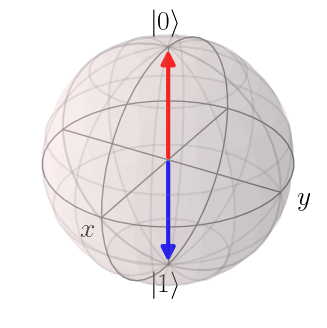

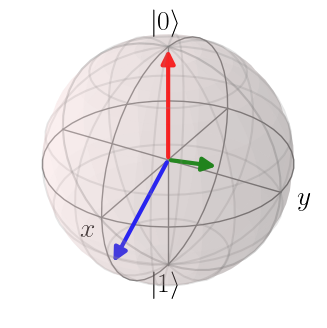

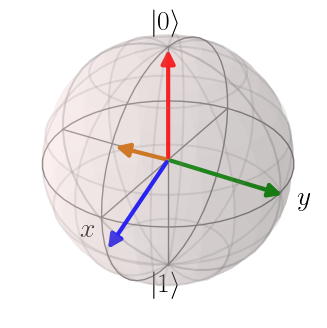

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configurar las opciones de estilo
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'Times New Roman'

# Crear una figura y un eje 3D
fig = plt.figure(figsize=(7, 3))
ax = fig.add_subplot(111, projection='3d')

cases = [
  (1,2, "1q-2c"),
  (1,3, "1q-3c"),
  (1,4, "1q-4c")
]

for case_i in cases:
  
  b = qutip.Bloch(axes=ax, fig=fig)
  b.make_sphere()
  
  states = representatives(case_i[1], case_i[0])
  states_sphr = [to_spherical(state_j) for state_j in states]
  states_cart = [to_cartesian(state_j) for state_j in states_sphr]
  for vec_i in states_cart:
    b.add_vectors(vec_i)
  b.vector_color = ['r', 'b', 'g', '#CC6600']
# Renderizar la esfera
  b.render()
  b.show()

  # Guardar la imagen en PDF con espacio en blanco ajustado
  path_to_save = os.path.join('results_to_paper', f"labeled_{case_i[2]}.pdf")

  # Ajustar el espacio en blanco y guardar la figura
  plt.savefig(path_to_save, bbox_inches='tight')  # Ajuste del espacio en blanco
  b.save(path_to_save)


TypeError: zeros() got an unexpected keyword argument 'requires_grad'

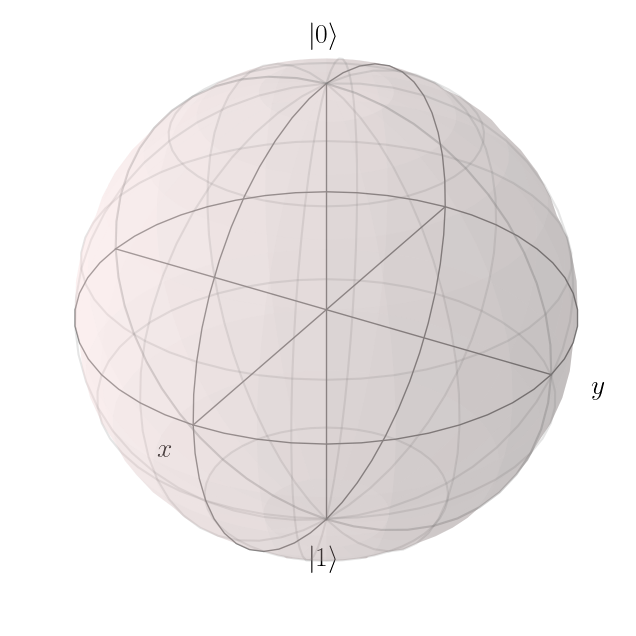

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import qutip

# Configurar las opciones de estilo
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'Times New Roman'

# Crear una figura y un eje 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Ejemplos de casos
cases = [
    (1, 2, "1q-2c"),
    (1, 3, "1q-3c"),
    (1, 4, "1q-4c")
]

for case_i in cases:
    # Crear esfera de Bloch
    b = qutip.Bloch(axes=ax, fig=fig)
    b.make_sphere()

    # Obtener los estados cuánticos y transformarlos a coordenadas esféricas
    states = representatives(case_i[1], case_i[0])
    states_sphr = [to_spherical(state_j) for state_j in states]
    states_cart = [to_cartesian(state_j) for state_j in states_sphr]

    

    # Definir los colores de los vectores
    b.vector_color = ['r', 'b', 'g', '#CC6600']

    # Renderizar la esfera
    b.render()
    

    # Guardar la imagen en PDF con espacio en blanco ajustado
    path_to_save = os.path.join('results_to_paper', f"labeled_{case_i[2]}.pdf")
    

    # Ajustar el espacio en blanco y guardar la figura
    plt.savefig(path_to_save, bbox_inches='tight')  # Ajuste del espacio en blanco
    b.save(path_to_save)
    b.show()


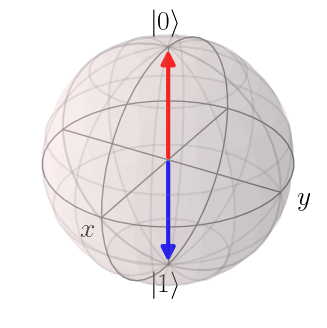

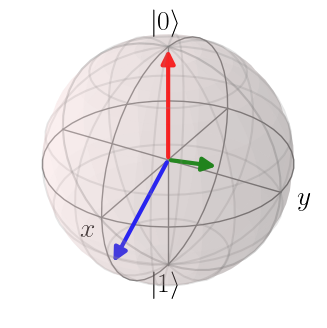

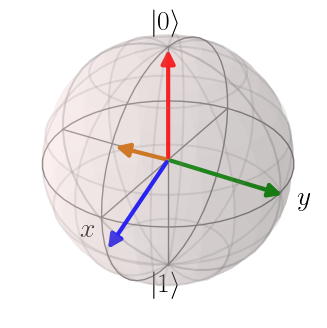

In [7]:
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import qutip

# Configurar las opciones de estilo
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'Times New Roman'

# Crear una figura y un eje 3D
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection='3d')

# Ejemplos de casos
cases = [
  (1, 2, "1q-2c"),
  (1, 3, "1q-3c"),
  (1, 4, "1q-4c")
]

for case_i in cases:
    # Crear esfera de Bloch
    b = qutip.Bloch(axes=ax, fig=fig)
    b.make_sphere()

    # Obtener los estados cuánticos y transformarlos a coordenadas esféricas
    states = representatives(case_i[1], case_i[0])
    states_sphr = [to_spherical(state_j) for state_j in states]
    states_cart = [to_cartesian(state_j) for state_j in states_sphr]
    
    for vec_i, sphr_coords in zip(states_cart, states_sphr):
        # Añadir el vector a la esfera de Bloch
        b.add_vectors(vec_i)
        
        # Extraer theta y phi, convertir a float, y redondear a 1 decimal
        theta = round(float(sphr_coords[1]), 1)
        phi = round(float(sphr_coords[2]), 1)

        # Colocar el texto en la punta del vector
        b.axes.text(vec_i[0], vec_i[1], vec_i[2], f"({theta}, {phi})", color='black')

    # Definir los colores de los vectores
    b.vector_color = ['r', 'b', 'g', '#CC6600']

    # Renderizar la esfera
    b.render()
    b.show()

    # Guardar la imagen en PDF
    path_to_save = os.path.join('results_to_paper', f"labeled_{case_i[2]}.pdf")
    b.save(path_to_save)


TypeError: zeros() got an unexpected keyword argument 'requires_grad'

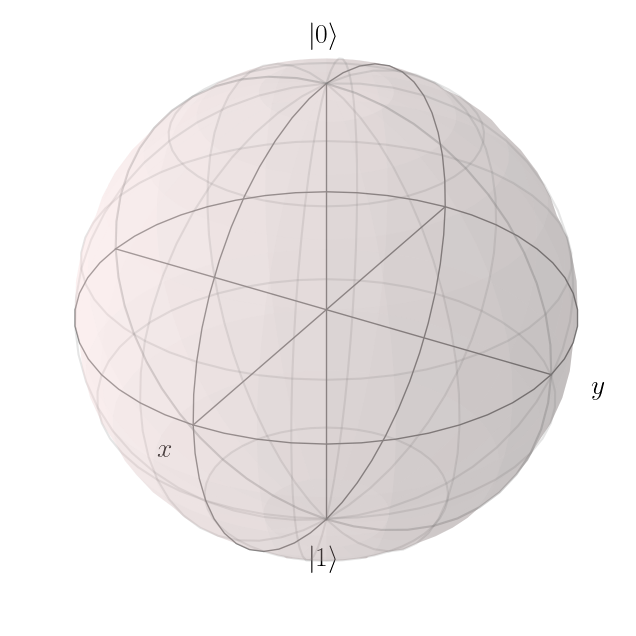

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import qutip

# Configurar las opciones de estilo
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'Times New Roman'

# Crear una figura y un eje 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Ejemplos de casos
cases = [
    (1, 2, "1q-2c"),
    (1, 3, "1q-3c"),
    (1, 4, "1q-4c")
]

for case_i in cases:
    # Crear esfera de Bloch
    b = qutip.Bloch(axes=ax, fig=fig)
    b.make_sphere()

    # Obtener los estados cuánticos y transformarlos a coordenadas esféricas
    states = representatives(case_i[1], case_i[0])
    states_sphr = [to_spherical(state_j) for state_j in states]
    states_cart = [to_cartesian(state_j) for state_j in states_sphr]

    for vec_i, sphr_coords in zip(states_cart, states_sphr):
        # Añadir el vector a la esfera de Bloch
        b.add_vectors(vec_i)
        
        # Extraer theta y phi, convertir a float, y redondear a 1 decimal
        theta = round(float(sphr_coords[1]), 1)
        phi = round(float(sphr_coords[2]), 1)

        # Colocar el texto en la punta del vector (ajustando la posición)
        # Se añaden ligeros offsets para que el texto no se superponga al vector
        offset = 0.1  # Ajusta este valor para desplazar el texto en el espacio
        x_text = vec_i[0] + offset
        y_text = vec_i[1] + offset
        z_text = vec_i[2] + offset
        b.axes.text(x_text, y_text, z_text, f"({theta}, {phi})", color='black', fontsize=10)

    # Definir los colores de los vectores
    b.vector_color = ['r', 'b', 'g', '#CC6600']

    # Renderizar la esfera
    b.render()
    b.show()

    # Guardar la imagen en PDF
    path_to_save = os.path.join('results_to_paper', f"labeled_{case_i[2]}.pdf")
    b.save(path_to_save)
